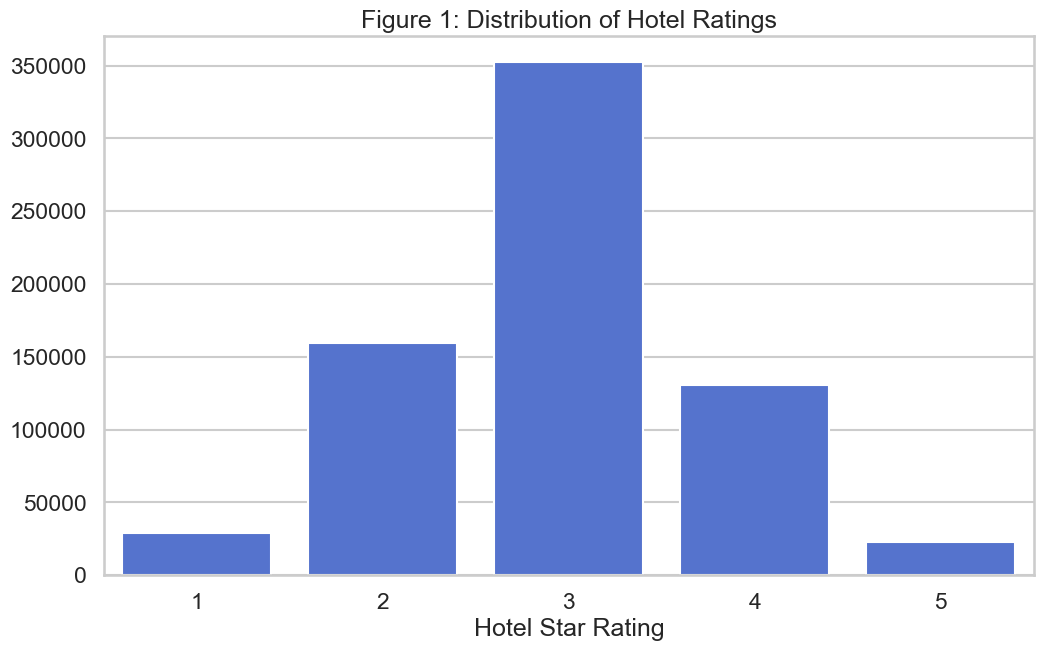

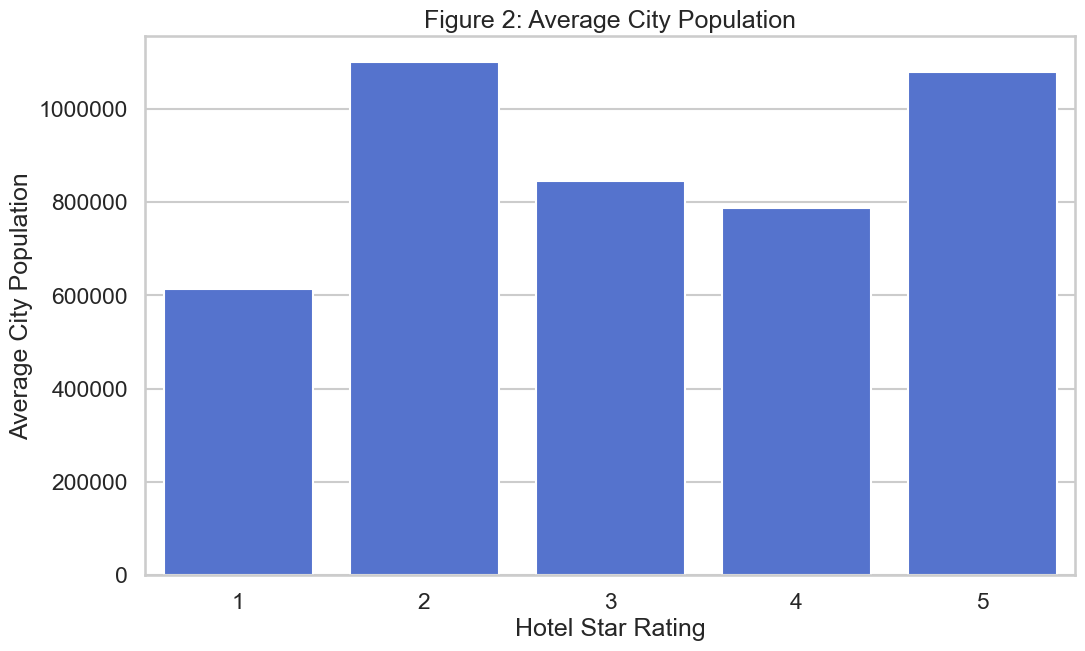

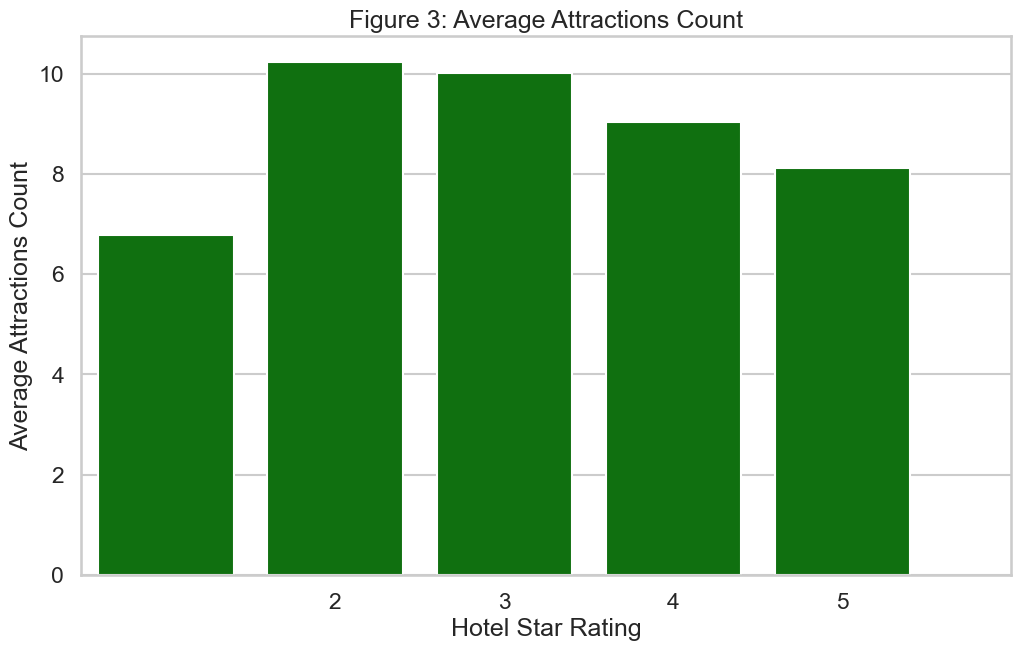

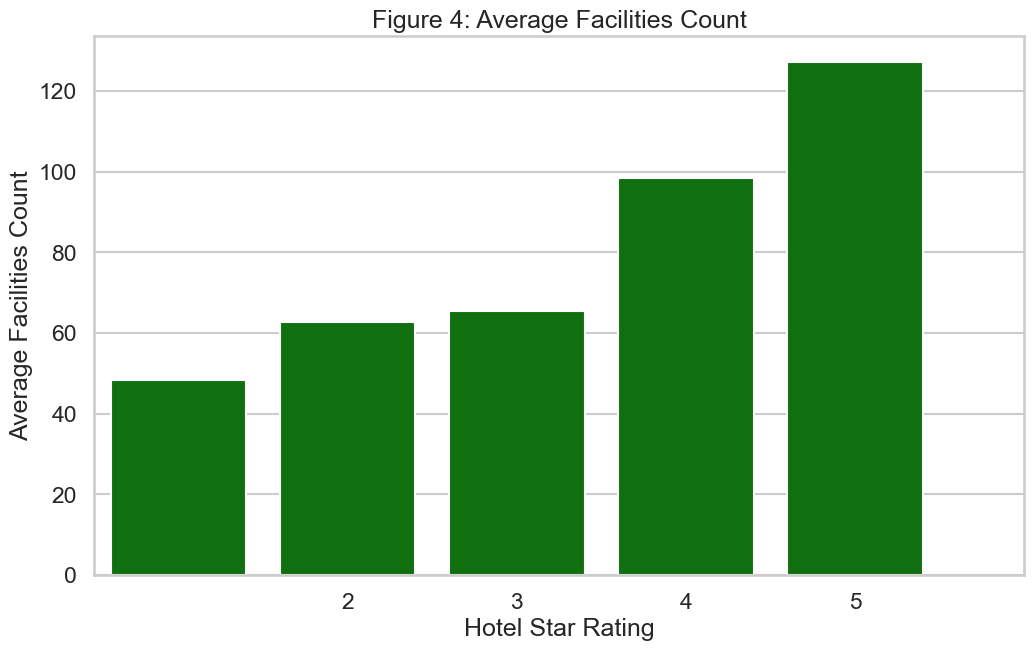

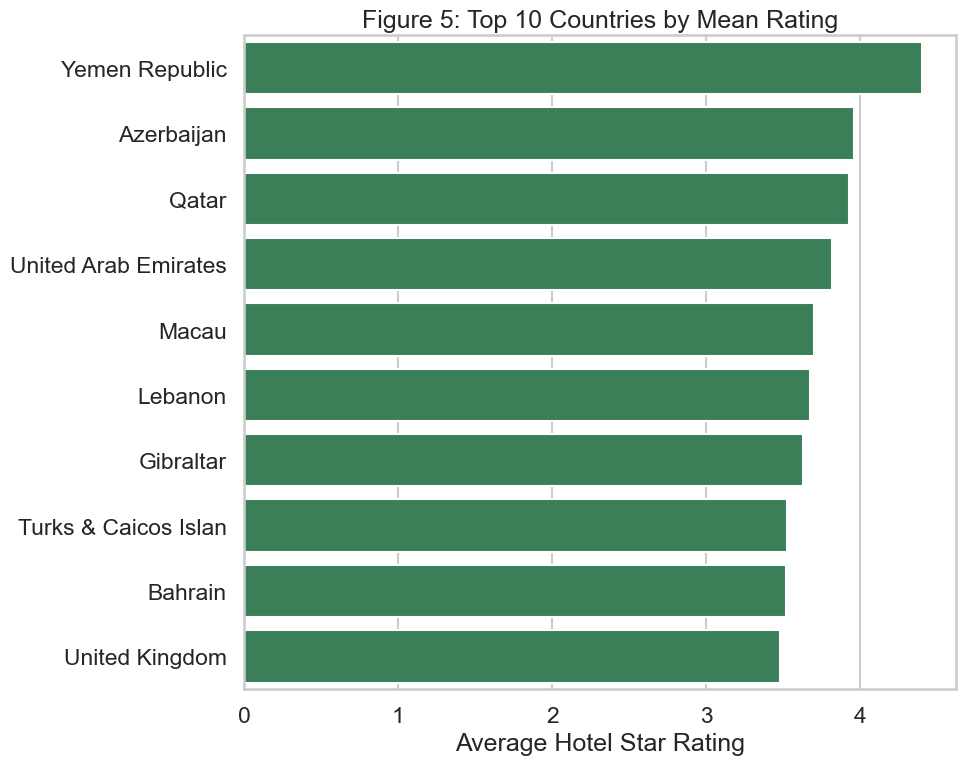

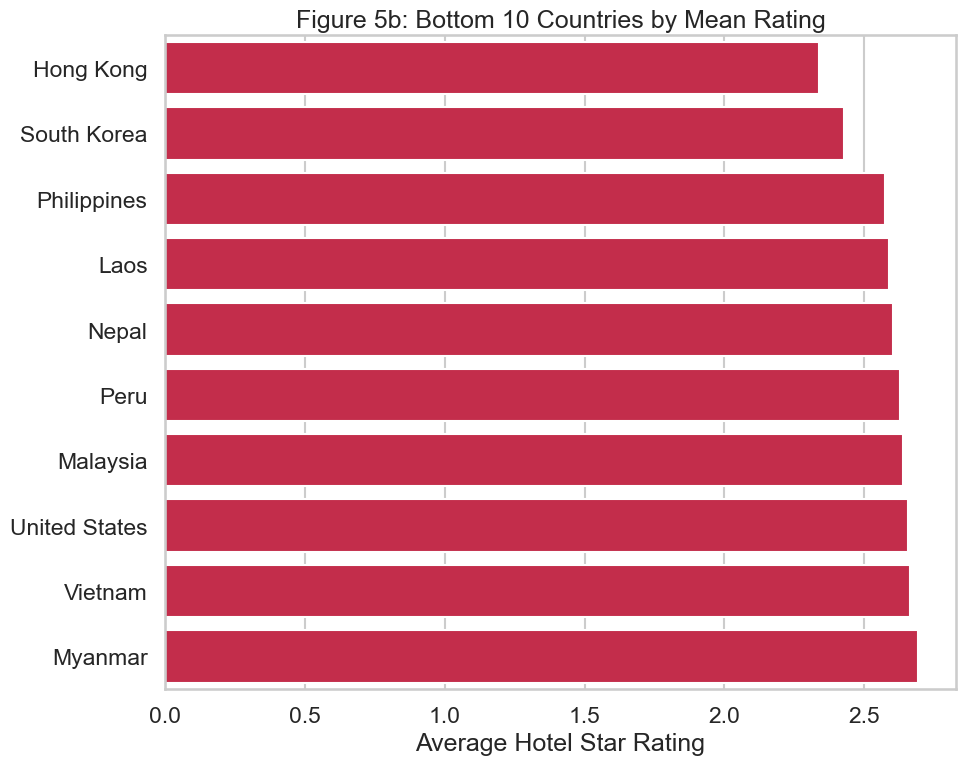

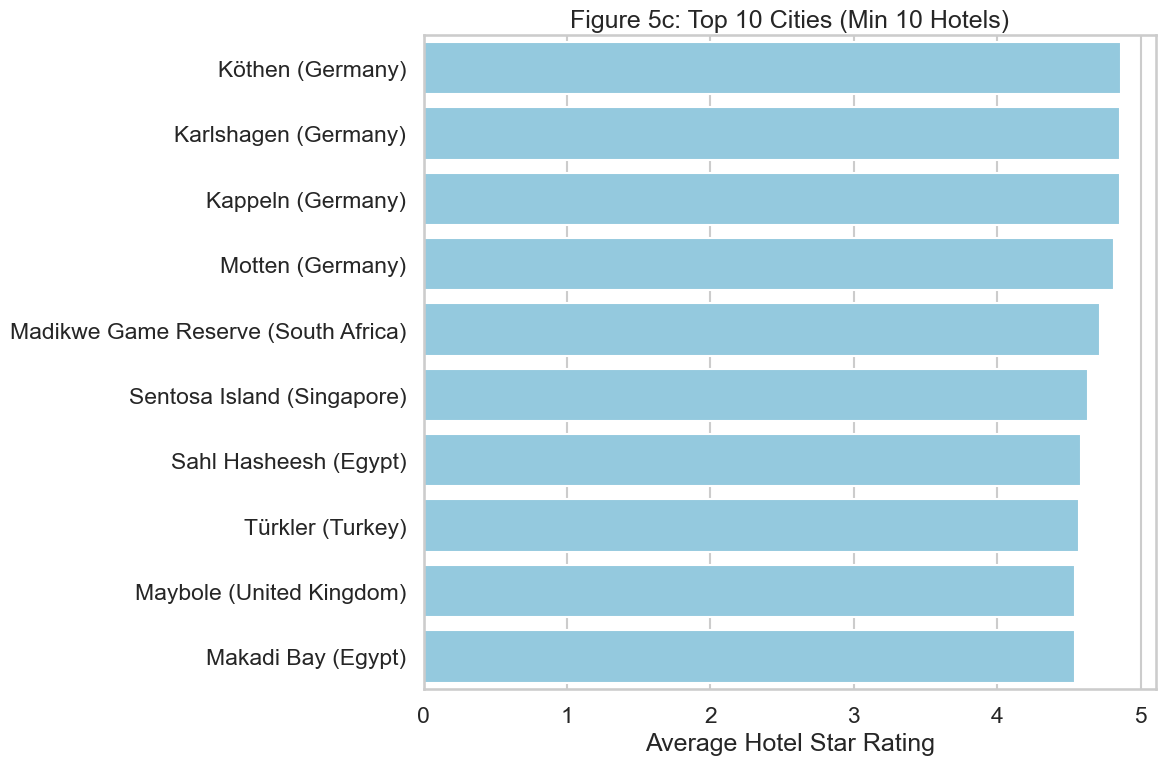

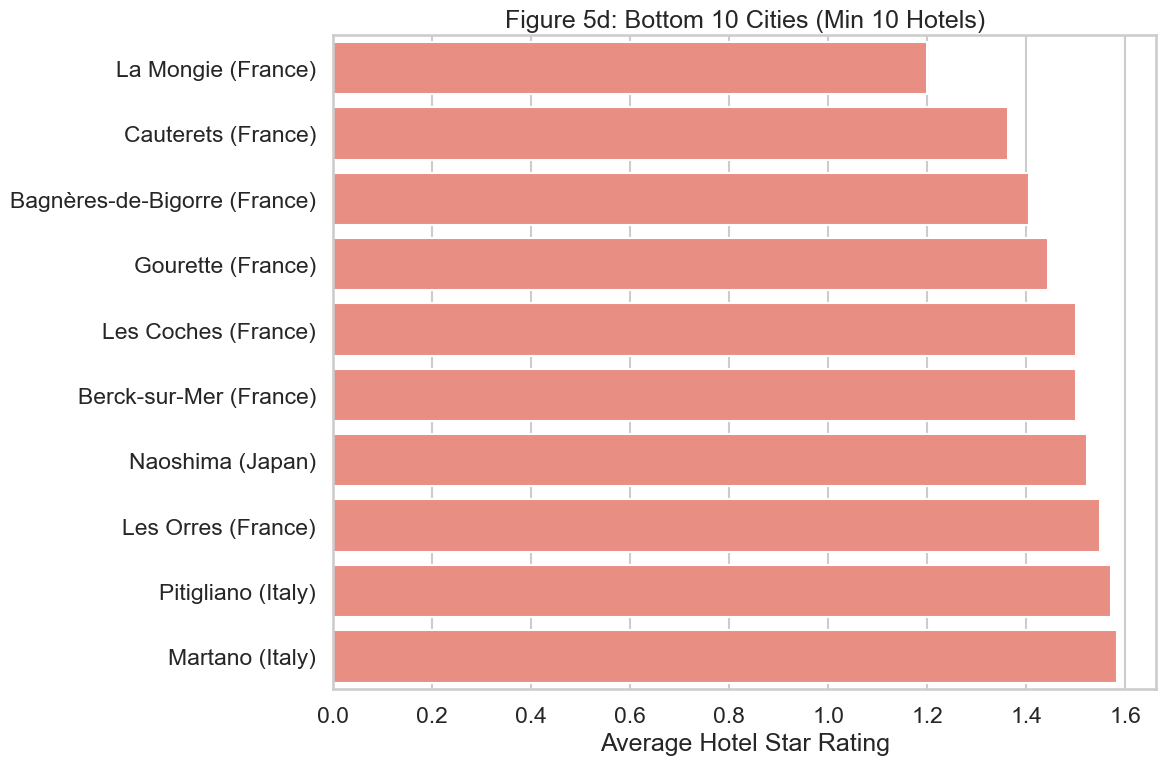

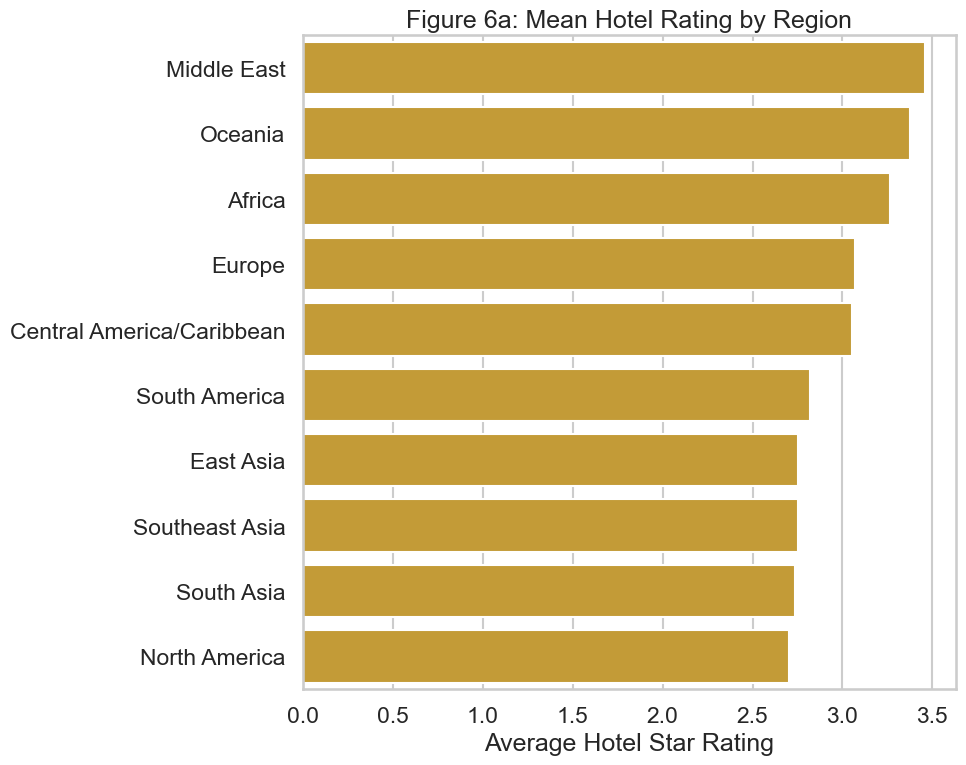

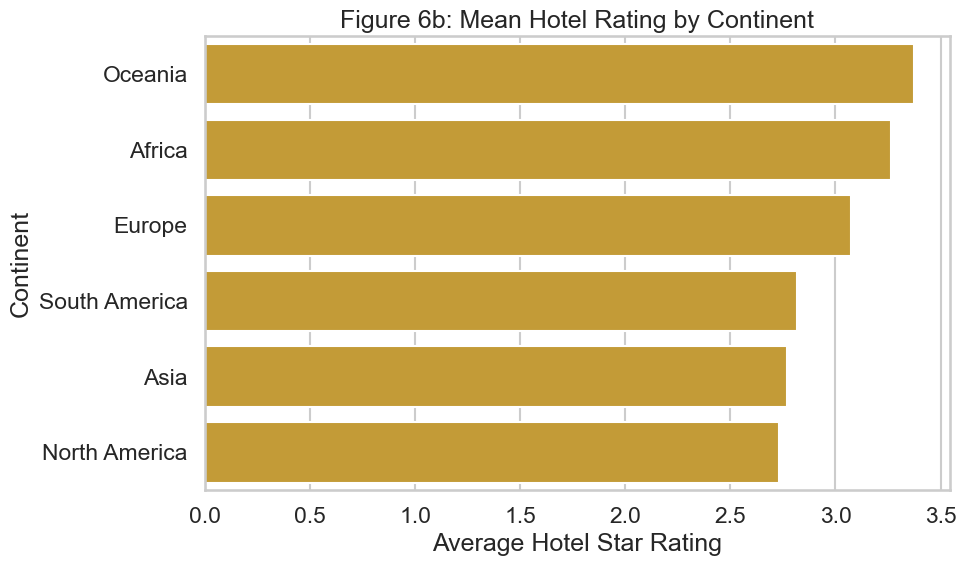

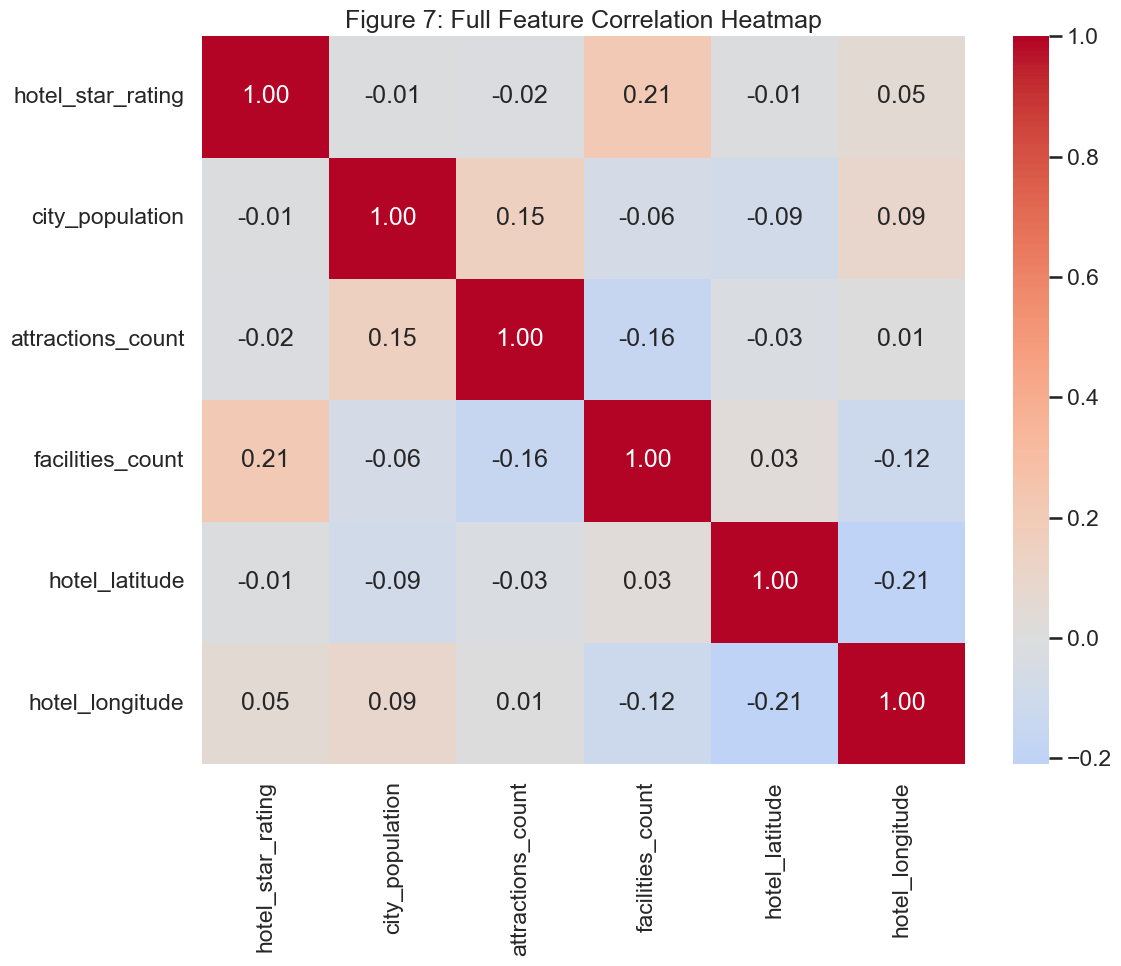

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data
df = pd.read_parquet('../../data/processed/hotels_with_cities-2.parquet')

# --- 1. Refined Sub-Region Mapping ---
region_map = {
    # NORTH AMERICA
    'United States': 'North America', 'Canada': 'North America', 'Mexico': 'North America',
    
    # SOUTH AMERICA
    'Argentina': 'South America', 'Bolivia': 'South America', 'Brazil': 'South America', 
    'Chile': 'South America', 'Colombia': 'South America', 'Ecuador': 'South America', 
    'Paraguay': 'South America', 'Peru': 'South America', 'Uruguay': 'South America', 
    'Venezuela': 'South America',

    # CENTRAL AMERICA & CARIBBEAN
    'Antigua': 'Central America/Caribbean', 'Aruba': 'Central America/Caribbean', 'Bahamas': 'Central America/Caribbean',
    'Barbados': 'Central America/Caribbean', 'Costa Rica': 'Central America/Caribbean', 'Dominican Republic': 'Central America/Caribbean',
    'Grenada': 'Central America/Caribbean', 'Guadeloupe': 'Central America/Caribbean', 'Guatemala': 'Central America/Caribbean',
    'Jamaica': 'Central America/Caribbean', 'Panama': 'Central America/Caribbean', 'Puerto Rico': 'Central America/Caribbean',
    'St Kitts & Nevis': 'Central America/Caribbean', 'St Lucia': 'Central America/Caribbean', 
    'St Vincent & Grenadi': 'Central America/Caribbean', 'Trinidad & Tobago': 'Central America/Caribbean',
    'Turks & Caicos Islan': 'Central America/Caribbean', 'Virgin Islands (USA)': 'Central America/Caribbean',

    # EAST ASIA
    'China': 'East Asia', 'Hong Kong': 'East Asia', 'Japan': 'East Asia', 
    'Macau': 'East Asia', 'Mongolia': 'East Asia', 'South Korea': 'East Asia', 'Taiwan': 'East Asia',

    # SOUTHEAST ASIA
    'Brunei Darussalam': 'Southeast Asia', 'Cambodia': 'Southeast Asia', 'Indonesia': 'Southeast Asia',
    'Laos': 'Southeast Asia', 'Malaysia': 'Southeast Asia', 'Myanmar': 'Southeast Asia',
    'Philippines': 'Southeast Asia', 'Singapore': 'Southeast Asia', 'Thailand': 'Southeast Asia',
    'Vietnam': 'Southeast Asia',

    # SOUTH ASIA
    'India': 'South Asia', 'Nepal': 'South Asia', 'Sri Lanka': 'South Asia',

    # MIDDLE EAST
    'Bahrain': 'Middle East', 'Israel': 'Middle East', 'Jordan': 'Middle East', 'Kuwait': 'Middle East',
    'Lebanon': 'Middle East', 'Oman': 'Middle East', 'Qatar': 'Middle East', 'Saudi Arabia': 'Middle East',
    'Turkey': 'Middle East', 'United Arab Emirates': 'Middle East', 'Yemen Republic': 'Middle East',

    # EUROPE
    'Albania': 'Europe', 'Andorra': 'Europe', 'Austria': 'Europe', 'Azerbaijan': 'Europe',
    'Belarus': 'Europe', 'Belgium': 'Europe', 'Bosnia Herzegovina': 'Europe', 'Bulgaria': 'Europe',
    'Croatia': 'Europe', 'Cyprus': 'Europe', 'Czech Republic': 'Europe', 'Denmark': 'Europe',
    'Estonia': 'Europe', 'Finland': 'Europe', 'France': 'Europe', 'Germany': 'Europe',
    'Gibraltar': 'Europe', 'Greece': 'Europe', 'Hungary': 'Europe', 'Iceland': 'Europe',
    'Ireland(Republic of)': 'Europe', 'Italy': 'Europe', 'Latvia': 'Europe', 'Liechtenstein': 'Europe',
    'Lithuania': 'Europe', 'Luxembourg': 'Europe', 'Malta': 'Europe', 'Monaco': 'Europe',
    'Netherlands': 'Europe', 'Norway': 'Europe', 'Poland': 'Europe', 'Portugal': 'Europe',
    'Romania': 'Europe', 'Russia': 'Europe', 'Russian Federation': 'Europe', 'San Marino': 'Europe',
    'Serbia': 'Europe', 'Slovakia': 'Europe', 'Slovenia': 'Europe', 'Spain': 'Europe',
    'Sweden': 'Europe', 'Switzerland': 'Europe', 'Ukraine': 'Europe', 'United Kingdom': 'Europe',

    # AFRICA
    'Botswana': 'Africa', 'Cameroon': 'Africa', 'Egypt': 'Africa', 'Ethiopia': 'Africa',
    'Kenya': 'Africa', 'Libya': 'Africa', 'Mauritius': 'Africa', 'Morocco': 'Africa',
    'Namibia': 'Africa', 'Nigeria': 'Africa', 'Senegal': 'Africa', 'Seychelles': 'Africa',
    'South Africa': 'Africa', 'Tanzania': 'Africa', 'Tunisia': 'Africa', 'Zambia': 'Africa',
    'Zimbabwe': 'Africa', 'Swaziland': 'Africa',

    # OCEANIA
    'Australia': 'Oceania', 'Cook Islands': 'Oceania', 'Fiji': 'Oceania', 'Guam': 'Oceania',
    'New Caledonia': 'Oceania', 'New Zealand': 'Oceania', 'Northern Mariana Isl': 'Oceania',
    'Palau': 'Oceania', 'Samoa': 'Oceania', 'Tonga': 'Oceania', 'Vanuatu': 'Oceania',
    'French Polynesia': 'Oceania'
}

# --- Map Sub-Regions to Main Continents ---
continent_map = {
    'North America': 'North America',
    'South America': 'South America',
    'Central America/Caribbean': 'North America', 
    'East Asia': 'Asia',
    'Southeast Asia': 'Asia',
    'South Asia': 'Asia',
    'Middle East': 'Asia',
    'Europe': 'Europe',
    'Africa': 'Africa',
    'Oceania': 'Oceania'
}

df['sub_region'] = df['countyName'].map(region_map).fillna('Other')
df['continent'] = df['sub_region'].map(continent_map).fillna('Other')

# Global styling
sns.set_context("talk")
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

# --- 2. Calculations ---
sub_region_stats = df.groupby('sub_region')['hotel_star_rating'].mean().sort_values(ascending=False)
continent_stats = df.groupby('continent')['hotel_star_rating'].mean().sort_values(ascending=False)
country_stats = df.groupby('countyName')['hotel_star_rating'].mean().dropna()
city_stats = df.groupby(['cityName', 'countyName'])['hotel_star_rating'].agg(['mean', 'count']).dropna().reset_index()
city_stats['city_label'] = city_stats['cityName'] + " (" + city_stats['countyName'] + ")"

reliable_cities = city_stats[city_stats['count'] >= 10]

top_10_countries = country_stats.sort_values(ascending=False).head(10)
worst_10_countries = country_stats.sort_values(ascending=True).head(10)
top_10_cities = reliable_cities.sort_values(by='mean', ascending=False).head(10)
worst_10_cities = reliable_cities.sort_values(by='mean', ascending=True).head(10)

# --- GENERATE PLOTS ---

# Figure 1: Distribution
plt.figure()
sns.countplot(data=df, x='hotel_star_rating', color='royalblue')
plt.title('Figure 1: Distribution of Hotel Ratings')
plt.xlabel('Hotel Star Rating')
plt.ylabel('')
plt.savefig('eda_1_rating_imbalance.png')

# Figure 2
plt.figure()
sns.barplot(data=df, x='hotel_star_rating', y='city_population', estimator=np.mean, errorbar=None, color='royalblue')

plt.ticklabel_format(style='plain', axis='y')
plt.title('Figure 2: Average City Population')
plt.xlabel('Hotel Star Rating')
plt.ylabel('Average City Population')
plt.savefig('eda_2_bar_pop.png')

# Figure 3
plt.figure()
sns.barplot(data=df, x='hotel_star_rating', y='attractions_count', estimator=np.mean, errorbar=None, color='green')
plt.title('Figure 3: Average Attractions Count')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks([1, 2, 3, 4, 5])
plt.xlabel('Hotel Star Rating')
plt.ylabel('Average Attractions Count')
plt.savefig('eda_3_rating_vs_attractions.png')

# Figure 4
plt.figure()
sns.barplot(data=df, x='hotel_star_rating', y='facilities_count', estimator=np.mean, errorbar=None, color='green')
plt.title('Figure 4: Average Facilities Count')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks([1, 2, 3, 4, 5])
plt.xlabel('Hotel Star Rating')
plt.ylabel('Average Facilities Count')
plt.savefig('eda_4_rating_vs_facilities.png')

# Figure 5: Top 10 Countries (Horizontal)
plt.figure(figsize=(10, 8))
sns.barplot(y=top_10_countries.index, x=top_10_countries.values, color='seagreen', orient='h')
plt.title('Figure 5: Top 10 Countries by Mean Rating')
plt.xlabel('Average Hotel Star Rating')
plt.ylabel('')
plt.tight_layout()
plt.savefig('eda_5_top_countries.png')

# Figure 5b: Worst 10 Countries (Horizontal)
plt.figure(figsize=(10, 8))
sns.barplot(y=worst_10_countries.index, x=worst_10_countries.values, color='crimson', orient='h')
plt.title('Figure 5b: Bottom 10 Countries by Mean Rating')
plt.xlabel('Average Hotel Star Rating')
plt.ylabel('')
plt.tight_layout()
plt.savefig('eda_5b_worst_countries.png')

# Figure 5c: Top 10 Cities (Horizontal)
plt.figure(figsize=(12, 8))
sns.barplot(y=top_10_cities['city_label'], x=top_10_cities['mean'], color='skyblue', orient='h')
plt.title('Figure 5c: Top 10 Cities (Min 10 Hotels)')
plt.xlabel('Average Hotel Star Rating')
plt.ylabel('')
plt.tight_layout()
plt.savefig('eda_5c_top_cities.png')

# Figure 5d: Worst 10 Cities (Horizontal)
plt.figure(figsize=(12, 8))
sns.barplot(y=worst_10_cities['city_label'], x=worst_10_cities['mean'], color='salmon', orient='h')
plt.title('Figure 5d: Bottom 10 Cities (Min 10 Hotels)')
plt.xlabel('Average Hotel Star Rating')
plt.ylabel('')
plt.tight_layout()
plt.savefig('eda_5d_worst_cities.png')

# Figure 6a: Sub-Region (Horizontal)
plt.figure(figsize=(10, 8))
sns.barplot(y=sub_region_stats.index, x=sub_region_stats.values, color='goldenrod', orient='h')
plt.title('Figure 6a: Mean Hotel Rating by Region')
plt.xlabel('Average Hotel Star Rating')
plt.ylabel('')
plt.tight_layout()
plt.savefig('eda_6a_rating_by_sub_region.png')

# Figure 6b: Rating by Continent
plt.figure(figsize=(10, 6))
sns.barplot(y=continent_stats.index, x=continent_stats.values, color='goldenrod', orient='h')
plt.title('Figure 6b: Mean Hotel Rating by Continent')
plt.xlabel('Average Hotel Star Rating')
plt.ylabel('Continent')
plt.tight_layout()
plt.savefig('eda_6b_rating_by_continent.png')

# Figure 7: Correlation
numeric_cols_all = [
    'hotel_star_rating', 
    'city_population', 
    'attractions_count', 
    'facilities_count',
    'hotel_latitude', 
    'hotel_longitude'
]

# Calculate the correlation matrix
corr_all = df[numeric_cols_all].corr()

# Create the plot without a mask to show the full square
fig, ax = plt.subplots(figsize=(12, 10))

# Draw the full square heatmap
sns.heatmap(
    corr_all, 
    annot=True, 
    cmap='coolwarm', 
    center=0, 
    fmt='.2f', 
    ax=ax
)

ax.set_title('Figure 7: Full Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('eda_7_square_heatmap.png')

plt.show()

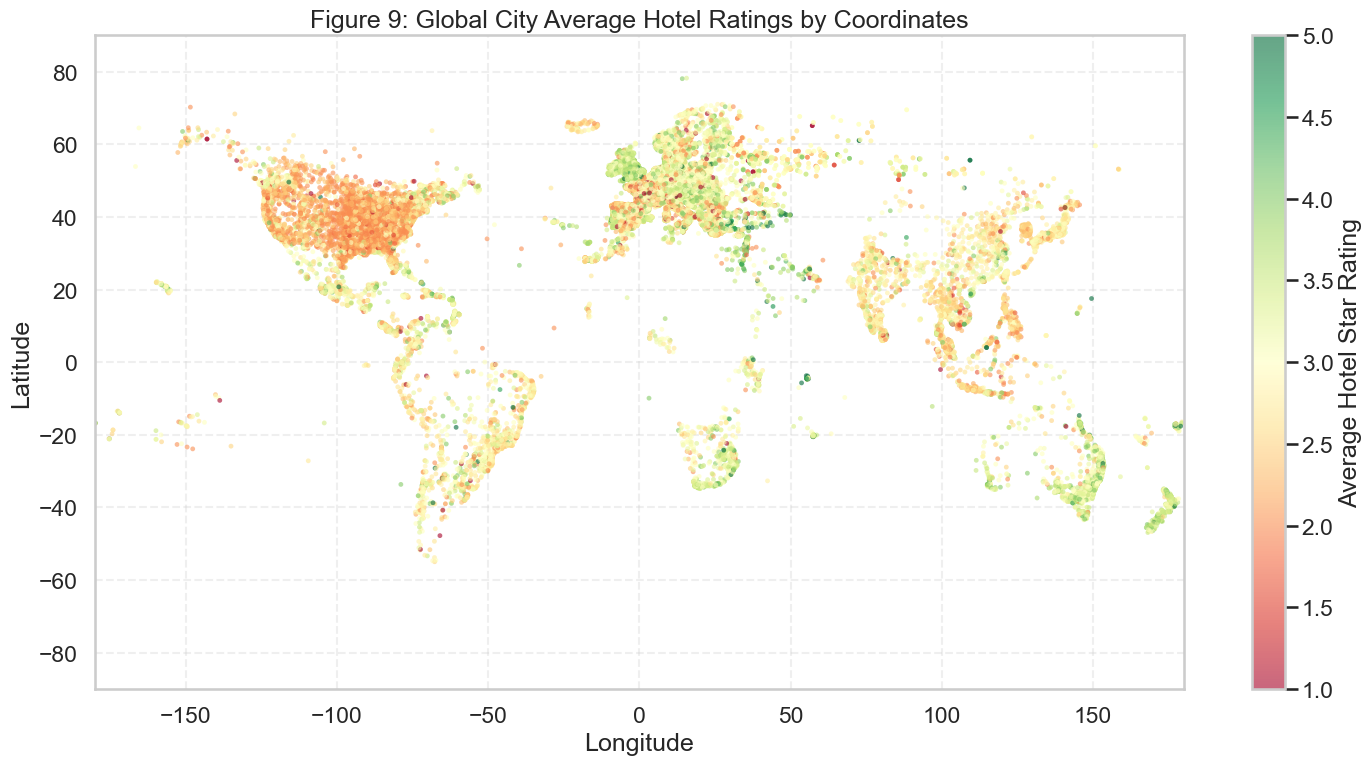

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_parquet('../../data/processed/hotels_with_cities-2.parquet')

city_map_data = df.groupby(['cityName', 'countyName']).agg({
    'hotel_star_rating': 'mean',
    'hotel_latitude': 'mean',
    'hotel_longitude': 'mean'
}).dropna().reset_index()

plt.figure(figsize=(15, 8))
scatter = plt.scatter(
    city_map_data['hotel_longitude'], 
    city_map_data['hotel_latitude'], 
    c=city_map_data['hotel_star_rating'],
    cmap='RdYlGn',
    s=12,
    alpha=0.6,
    edgecolors='none'
)

plt.colorbar(scatter, label='Average Hotel Star Rating')

plt.title('Figure 9: Global City Average Hotel Ratings by Coordinates')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.3)

plt.xlim(-180, 180)
plt.ylim(-90, 90)

plt.tight_layout()
plt.savefig('city_rating_coord_map.png')
plt.show()

# Insights

About Figure 1 and the distribution of hotel ratings, while it was initially expected that hotel ratings would cluster between 3 and 5 stars which would have resulted in limited variance, Figure 1 shows that the actual distribution is almost symmetric and follows a bell shaped curve centered at 3. This symmetry indicates that the dataset is highly balanced and representative of the global market. Because the ratings are not skewed toward a specific quality level, the data provides a reliable baseline where the mid range experience is the most common, and extreme budget or luxury options exist as equally distributed outliers.

Figure 2 shows that there is not much of a clear trend between hotel ratings and population. The results demonstrate that both 2 star and 5 star hotels are located in the largest metropolitan areas with averages over 1 million residents. Meanwhile, the figures for 3 star and 4 star hotels show a lower average population which indicates these categories do not follow a simple upward trajectory. The 1 star rating is associated with the lowest average population but the overall lack of a consistent pattern suggests that population is not a strong predictor for hotel quality levels in this dataset.

Figure 3 shows that there is not much of a clear trend between hotel ratings and attraction counts. The results reveal that 2 star and 3 star hotels are located in areas with the highest average attraction counts, exceeding 10.00 per city. Meanwhile, the figures for 4 star and 5 star hotels show a lower average count, which indicates these categories do not follow a simple upward trajectory. The 1 star rating is associated with the lowest average attraction count of 6.78, but the overall lack of a consistent pattern suggests that attraction density is not a strong predictor for hotel quality levels in this dataset.

Figure 4 reveals a clear and consistent positive trend between hotel star ratings and average facility counts. Unlike the previous metrics, this data follows a distinct upward trajectory, starting at 48.31 for 1-star hotels and climbing significantly to 127.27 for 5-star properties. This steady increase suggests that, unlike population or attraction density, the number of onsite facilities is a reliable indicator of a hotel's star rating.x

Figures 5 and 6 show that the geographic analysis reveals significant variance at national and city levels. Yemen and Qatar lead the top countries with averages near 4.0, while major markets like the United States and South Korea fall into the bottom ten with averages between 2.4 and 2.6. At the city level, Germany dominates the top performers with several cities averaging above 4.8. In contrast, France accounts for the majority of the bottom ten cities, with several locations averaging below 1.5 stars. Regionally, the Middle East maintains the highest average at 3.46, while North America sits at the bottom with 2.70. These results demonstrate that while broad regions hover near a 3.0 average, specific countries and cities exhibit extreme diversity in hotel standards.

The results from atmap demonstrate that there is not much of a clear trend between hotel ratings and any of the external factors. The only notable relationship exists between hotel_star_rating and facilities_count with a correlation of 0.21. While this is the strongest link in the data, it is still relatively weak, suggesting that while more amenities generally lead to higher ratings, they are not the sole factor.